# Wine Quality Prediction

Wine quality prediction is a real-world machine learning problem where the quality of wine is estimated based on its chemical characteristics. These characteristics include attributes such as acidity, density, alcohol content, and sulphates.

This project aims to analyze a wine dataset and build classification models to predict wine quality. By applying different machine learning algorithms, the project demonstrates how data-driven techniques can be used in the field of viticulture to support quality assessment.

## Objective

The objective of this project is to predict the quality of wine using its chemical properties by applying multiple machine learning classification algorithms and evaluating their performance.

## Dataset Description

The dataset contains physicochemical properties of wine samples along with a quality score. Each row represents a wine sample, and each column represents a specific chemical attribute that influences wine quality.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load the dataset
df = pd.read_csv("WineQT.csv")

# Display first few rows
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4


## Initial Data Exploration

Initial exploration is performed to understand the structure of the dataset, data types of features, and basic statistical information.

In [3]:
df.shape

(1143, 13)

In [4]:
# Dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1143 non-null   float64
 1   volatile acidity      1143 non-null   float64
 2   citric acid           1143 non-null   float64
 3   residual sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free sulfur dioxide   1143 non-null   float64
 6   total sulfur dioxide  1143 non-null   float64
 7   density               1143 non-null   float64
 8   pH                    1143 non-null   float64
 9   sulphates             1143 non-null   float64
 10  alcohol               1143 non-null   float64
 11  quality               1143 non-null   int64  
 12  Id                    1143 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 116.2 KB


## Exploratory Data Analysis

In this section, the dataset is explored to understand the distribution of features, identify patterns, and gain insights into the chemical properties that influence wine quality. Summary statistics and visual exploration help in understanding the range and behavior of the variables.

In [5]:
# Statistical summary
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
count,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000
mean,8.311111,0.531339,0.268364,2.532152,0.086933,15.615486,45.914698,0.996730,3.311015,0.657708,10.442111,5.657043,804.969379
std,1.747595,0.179633,0.196686,1.355917,0.047267,10.250486,32.782130,0.001925,0.156664,0.170399,1.082196,0.805824,463.997116
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000,0.000000
25%,7.100000,0.392500,0.090000,1.900000,0.070000,7.000000,21.000000,0.995570,3.205000,0.550000,9.500000,5.000000,411.000000
50%,7.900000,0.520000,0.250000,2.200000,0.079000,13.000000,37.000000,0.996680,3.310000,0.620000,10.200000,6.000000,794.000000
75%,9.100000,0.640000,0.420000,2.600000,0.090000,21.000000,61.000000,0.997845,3.400000,0.730000,11.100000,6.000000,1209.500000
max,15.900000,1.580000,1.000000,15.500000,0.611000,68.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000,1597.000000


In [6]:
# Distribution of wine quality scores
df['quality'].value_counts().sort_index()

quality
3      6
4     33
5    483
6    462
7    143
8     16
Name: count, dtype: int64

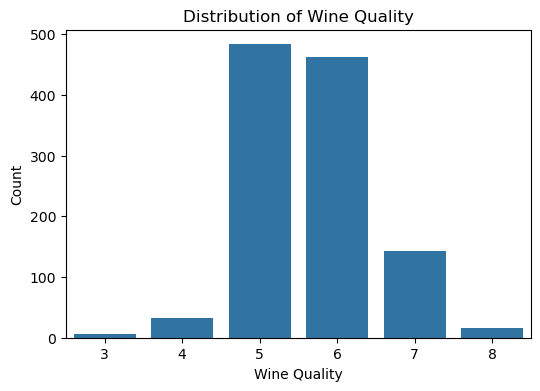

In [7]:
plt.figure(figsize=(6,4))
sns.countplot(x='quality', data=df)
plt.title("Distribution of Wine Quality")
plt.xlabel("Wine Quality")
plt.ylabel("Count")
plt.show()

## Data Cleaning

Before building machine learning models, the dataset is cleaned to ensure data quality and reliability. This includes checking for missing values and verifying that the data is suitable for further analysis.

In [8]:
# Check for missing values in the dataset
df.isnull().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
Id                      0
dtype: int64

## Feature Selection

Feature selection involves identifying the relevant input variables (chemical properties) that are used to predict the quality of wine. In this dataset, all chemical attributes are used as features, while the wine quality score is treated as the target variable.

In [9]:
# Separate features and target variable
X = df.drop('quality', axis=1)
y = df['quality']

# Display feature names
X.columns

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'Id'],
      dtype='object')

In [10]:
# Check the shape of features and target
X.shape, y.shape

((1143, 12), (1143,))

## Train–Test Split

To evaluate the performance of the wine quality prediction models, the dataset is divided into training and testing sets.  
The training data is used to train the models, while the testing data is used to assess how well the models generalize to unseen data.

In [11]:
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Check the shapes after splitting
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((914, 12), (229, 12), (914,), (229,))

## Model Training – Random Forest Classifier

In this step, a Random Forest Classifier is trained to predict wine quality based on chemical characteristics.  
Random Forest is an ensemble learning method that combines multiple decision trees to improve prediction accuracy and reduce overfitting.

In [12]:
from sklearn.ensemble import RandomForestClassifier

# Initialize the Random Forest model
rf_model = RandomForestClassifier(random_state=42)

# Train the model
rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

## Model Evaluation – Random Forest Classifier

In this step, the performance of the Random Forest model is evaluated using standard classification metrics.  
These metrics help assess how well the model predicts wine quality on unseen test data.

In [13]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Make predictions on test data
y_pred_rf = rf_model.predict(X_test)

# Accuracy
accuracy_rf = accuracy_score(y_test, y_pred_rf)
accuracy_rf

0.6812227074235808

In [14]:
# Detailed classification report
print(classification_report(y_test, y_pred_rf, zero_division=0))

              precision    recall  f1-score   support

           4       0.00      0.00      0.00         6
           5       0.73      0.75      0.74        96
           6       0.63      0.70      0.66        99
           7       0.75      0.58      0.65        26
           8       0.00      0.00      0.00         2

    accuracy                           0.68       229
   macro avg       0.42      0.40      0.41       229
weighted avg       0.66      0.68      0.67       229



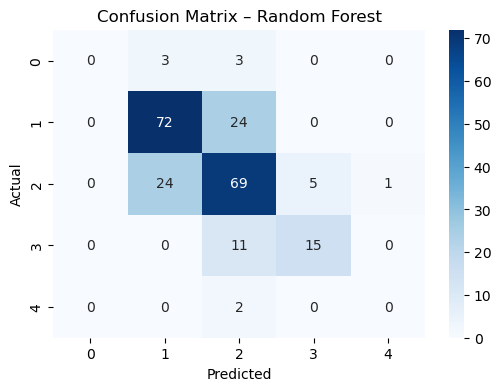

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix – Random Forest')
plt.show()

## Stochastic Gradient Descent (SGD) Classifier

This model applies stochastic optimization to efficiently train a linear classifier for wine quality prediction and is suitable for large-scale datasets.

In [16]:
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import accuracy_score, classification_report

# Initialize SGD Classifier
sgd_model = SGDClassifier(random_state=42)

# Train the model
sgd_model.fit(X_train, y_train)

# Predictions
y_pred_sgd = sgd_model.predict(X_test)

# Accuracy
accuracy_sgd = accuracy_score(y_test, y_pred_sgd)
accuracy_sgd

0.5327510917030568

In [17]:
print(classification_report(y_test, y_pred_sgd, zero_division=0))

              precision    recall  f1-score   support

           4       0.00      0.00      0.00         6
           5       0.74      0.33      0.46        96
           6       0.48      0.91      0.63        99
           7       0.00      0.00      0.00        26
           8       0.00      0.00      0.00         2

    accuracy                           0.53       229
   macro avg       0.25      0.25      0.22       229
weighted avg       0.52      0.53      0.47       229



## Support Vector Classifier (SVC)

Support Vector Classifier is a powerful supervised learning algorithm that finds the optimal hyperplane to separate different wine quality classes.

In [18]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

# Initialize SVC model
svc_model = SVC(kernel='rbf', random_state=42)

# Train the model
svc_model.fit(X_train, y_train)

# Predictions
y_pred_svc = svc_model.predict(X_test)

# Accuracy
accuracy_svc = accuracy_score(y_test, y_pred_svc)
accuracy_svc

0.49344978165938863

In [19]:
print(classification_report(y_test, y_pred_svc, zero_division=0))

              precision    recall  f1-score   support

           4       0.00      0.00      0.00         6
           5       0.49      0.64      0.55        96
           6       0.50      0.53      0.51        99
           7       0.00      0.00      0.00        26
           8       0.00      0.00      0.00         2

    accuracy                           0.49       229
   macro avg       0.20      0.23      0.21       229
weighted avg       0.42      0.49      0.45       229



## Model Comparison

In this step, the performance of different classification models is compared using accuracy to identify the most effective model for wine quality prediction.

In [20]:
import pandas as pd

model_comparison = pd.DataFrame({
    'Model': ['Random Forest', 'SGD Classifier', 'Support Vector Classifier'],
    'Accuracy': [accuracy_rf, accuracy_sgd, accuracy_svc]
})

model_comparison

,Model,Accuracy
0,Random Forest,0.681223
1,SGD Classifier,0.532751
2,Support Vector Classifier,0.493450


## Model Performance Visualization

A bar chart is used to visually compare the accuracy of all trained models.

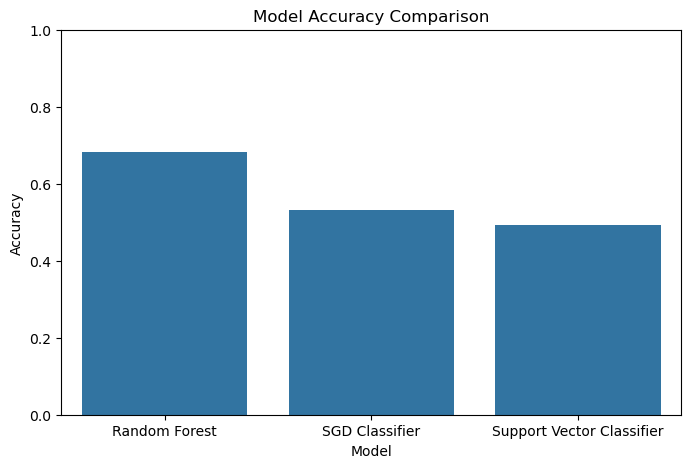

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.barplot(x='Model', y='Accuracy', data=model_comparison)
plt.title('Model Accuracy Comparison')
plt.ylim(0,1)
plt.show()

## Best Model Selection

Based on the evaluation results, the Random Forest Classifier is selected as the best model as it achieved the highest accuracy compared to the SGD Classifier and Support Vector Classifier (SVC), demonstrating better overall predictive performance and reliability on the given dataset.

## Conclusion

This project successfully applied machine learning techniques for wine quality prediction, and after comparing Random Forest, SGD, and SVC models, the Random Forest Classifier emerged as the best-performing model due to its higher accuracy, robustness, and effective handling of complex feature interactions.